In [7]:
import os
import glob
import numpy as np
import nibabel as nib
import pandas as pd
from scipy.ndimage import binary_closing, binary_fill_holes
from skimage.measure import label

# ----------------------------
# CONFIG
# ----------------------------

DATA_ROOT = "../../data"   # contains sub-*/func/
OUT_DIR = "snr_outputs"
os.makedirs(OUT_DIR, exist_ok=True)

MASK_PERCENTILE = 60.0
EPS = 1e-6  # numerical safety

# ----------------------------
# HELPERS
# ----------------------------

def load_volume(path):
    if path.endswith(".npy"):
        return np.load(path)
    return nib.load(path).get_fdata()


def build_brain_mask_from_mean(vol4d):
    """
    Build mask from mean over time (same idea as echo1 mask).
    """
    mean_img = np.mean(vol4d, axis=-1)
    nonzero = mean_img[mean_img > 0]

    thr = np.percentile(nonzero, MASK_PERCENTILE)
    mask = mean_img > thr

    mask = binary_closing(mask, structure=np.ones((3, 3, 3)))
    mask = binary_fill_holes(mask)

    labels = label(mask)
    largest_cc = np.argmax(np.bincount(labels.flat)[1:]) + 1
    return labels == largest_cc


def compute_snr_adjacent_diff(vol4d, mask):
    """
    Adjacent-difference SNR:
    SNR = mean(signal_t) / (std(diff(signal_t)) / sqrt(2))
    """
    mean_t = np.mean(vol4d, axis=-1)

    diff_t = np.diff(vol4d, axis=-1)
    noise = np.std(diff_t, axis=-1) / np.sqrt(2)

    snr = mean_t / (noise + 1e-6)
    return snr[mask]



# ----------------------------
# MAIN
# ----------------------------

subjects = sorted(glob.glob(os.path.join(DATA_ROOT, "sub-*")))
rows = []

print(f"Found {len(subjects)} subjects")

for subj_dir in subjects:
    subject_id = os.path.basename(subj_dir)
    if subject_id == "sub-04620" or subject_id == "sub-11310":
        continue
    func_dir = os.path.join(subj_dir, "func")

    echo_files = sorted(glob.glob(os.path.join(func_dir, "*echo*.nii*")))

    if len(echo_files) != 4:
        print(f"{subject_id}: expected 4 echoes, found {len(echo_files)}")
        continue

    print(f"\n=== {subject_id} ===")

    echo_snrs = []

    for i, echo_path in enumerate(echo_files):
        vol = load_volume(echo_path)  # (64,64,30,239)

        if vol.ndim != 4:
            raise ValueError(f"{echo_path} is not 4D")

        if i == 0:
            mask = build_brain_mask_from_mean(vol)

        snr_vals = compute_snr_adjacent_diff(vol, mask)
        echo_snrs.append(np.mean(snr_vals))


    rows.append({
        "subject": subject_id,
        "snr_echo1": echo_snrs[0],
        "snr_echo2": echo_snrs[1],
        "snr_echo3": echo_snrs[2],
        "snr_echo4": echo_snrs[3],
    })
    for key in rows[-1]:
        print(f"{key}: {rows[-1][key]}")

# ----------------------------
# SAVE + SUMMARY
# ----------------------------

df = pd.DataFrame(rows)
csv_path = os.path.join(OUT_DIR, "snr_per_echo_time_domain.csv")
df.to_csv(csv_path, index=False)

print(f"\nSaved SNR CSV: {csv_path}")

print("\nGroup-level mean SNR per echo:")
print(df[["snr_echo1", "snr_echo2", "snr_echo3", "snr_echo4"]].mean())


Found 80 subjects

=== sub-04570 ===
subject: sub-04570
snr_echo1: 67.2988641730496
snr_echo2: 43.99061594829841
snr_echo3: 31.07452980747469
snr_echo4: 23.02019181607166

=== sub-04710 ===
subject: sub-04710
snr_echo1: 73.7621645162822
snr_echo2: 47.93925382565001
snr_echo3: 33.927220135094466
snr_echo4: 25.010587311743652

=== sub-04800 ===
subject: sub-04800
snr_echo1: 105.11193656776028
snr_echo2: 68.91189835546629
snr_echo3: 49.36486462498391
snr_echo4: 36.05327954655706

=== sub-16053 ===
subject: sub-16053
snr_echo1: 53.84232122720067
snr_echo2: 36.145284156248074
snr_echo3: 25.69997360099994
snr_echo4: 18.900521392450624

=== sub-17821 ===
subject: sub-17821
snr_echo1: 95.31135881812413
snr_echo2: 59.534642522969484
snr_echo3: 42.85011808608011
snr_echo4: 31.87768959865325

=== sub-19284 ===
subject: sub-19284
snr_echo1: 69.7944928869503
snr_echo2: 46.19948906309261
snr_echo3: 32.77984036248856
snr_echo4: 24.05529733798686

=== sub-19774 ===
subject: sub-19774
snr_echo1: 104.16

In [8]:
plot_df = df.head(5)

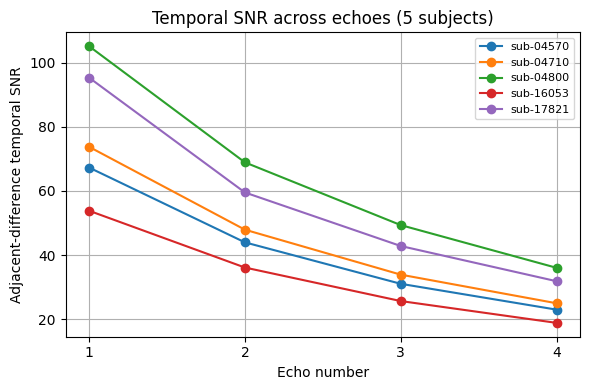

In [9]:
import matplotlib.pyplot as plt
import numpy as np

echo_idx = np.arange(1, 5)

plt.figure(figsize=(6, 4))

for _, row in plot_df.iterrows():
    snrs = [
        row["snr_echo1"],
        row["snr_echo2"],
        row["snr_echo3"],
        row["snr_echo4"],
    ]
    plt.plot(echo_idx, snrs, marker="o", label=row["subject"])

plt.xlabel("Echo number")
plt.ylabel("Adjacent-difference temporal SNR")
plt.title("Temporal SNR across echoes (5 subjects)")
plt.xticks(echo_idx)
plt.grid(True)
plt.legend(fontsize=8)

plt.tight_layout()
plt.show()
